In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
from Bio.Data import CodonTable
import sys
sys.path.append("variantDetector")
from utils import *

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm
import scipy, pysam, statsmodels
from matplotlib.colors import ListedColormap
from collections import Counter
from dna_features_viewer import GraphicFeature, GraphicRecord

h37Rv_path = "~/MtbLongitudinalDiversity/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv.gz"), compression='gzip')
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    # print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='insertion seqs and phages'").iterrows():
    insertion_seqs_phages_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = np.unique(insertion_seqs_phages_pos)

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv").dropna(subset='Lineage')

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants_WHO_catalog.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

mixed_samples = df_trust_patients.query("F2 > 0.03").SampleID.unique()

def get_RvID_from_gff(attr_str):
    """
    Parse the attributes column of a GFF line.
    Returns a dict of key:value pairs.
    """
    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['ID'].split('-')[-1]


def get_geneName_from_gff(attr_str):

    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['Name']

F2_max = 0.03

df_who_variants = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
genes_with_awR_mutations = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

cc_df = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/drug_CC.csv")

# Count how many SNPs go from Absent to Fixation

### and see if this agrees with expected mutation rate for Mtb: 0.3-0.5 SNPs / genome / year

In [2]:
AF_thresh = 0.95

df_longitudinal_pids = pd.read_csv(f"{TRUST_data_dir}/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids with longitudinal sequencing")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

# # additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.groupby('pid')['mix_phylotypes'].nunique()).query("mix_phylotypes == 1").index.values
pids_with_same_lineage = np.unique(list(pids_with_same_lineage))

pids_with_same_lineage_and_low_F2 = list(set(pids_with_low_F2).intersection(pids_with_same_lineage))
print(f"{len(pids_with_same_lineage_and_low_F2)} pids have F2 ≤ {F2_max} and matching lineages between timepoints")

df_longitudinal_pids = df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2").reset_index(drop=True)

df_longitudinal_pids['Sampling_Interval'] = df_longitudinal_pids.groupby('pid')['Sampling_Week'].transform(lambda x: np.max(x) - np.min(x))
print(f"    Sampling interval: median = {df_longitudinal_pids.Sampling_Interval.median()}, mean = {df_longitudinal_pids.Sampling_Interval.mean()}")

325 pids with longitudinal sequencing
285 pids have F2 ≤ 0.03 and matching lineages between timepoints
    Sampling interval: median = 6.0, mean = 5.5017543859649125


In [3]:
def get_pilon_fixed_variants(pilon_fName, AF_min=0.95, MQ_thresh=40, num_support=10):
    
    df_variants = read_pilon_vcf(pilon_fName)

    df_variants['AF'] = df_variants['AF'].astype(float)
    df_variants['DP'] = df_variants['DP'].astype(int)
    df_variants['MQ'] = df_variants['MQ'].astype(int)
    
    df_fixed_variants = df_variants.query("ALT!='.' & MQ >= @MQ_thresh")

    # there won't be any fixed variants here because they will all have an ALT allele
    df_unfixed_variants = df_variants.query("ALT=='.'")

    # only do this for the variants with NA in the ALT and AF columns. Make use of pilon's output AF because it is weighted by base and mapping qualities
    df_fixed_variants[['ALT', 'AO']] = df_fixed_variants.apply(lambda row: get_alt_allele(row["BC"], row["REF"]), axis=1, result_type="expand")
    df_unfixed_variants[['ALT', 'AO']] = df_unfixed_variants.apply(lambda row: get_alt_allele(row["BC"], row["REF"]), axis=1, result_type="expand")

    # recompute new AF
    df_fixed_variants['AF'] = df_fixed_variants['AO'] / df_fixed_variants['DP']
    df_unfixed_variants['AF'] = df_unfixed_variants['AO'] / df_unfixed_variants['DP']

    # return df_fixed_variants.query("AF > @AF_min & AO >= @num_support").reset_index(drop=True)
    return pd.concat([df_fixed_variants, df_unfixed_variants]).query("AO >= @num_support").reset_index(drop=True)

In [6]:
# df_variants = []

# for i, sample in enumerate(df_longitudinal_pids.SampleID.values):
    
#     pilon_VCF = f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.excludeLowConf.vcf" 
    
#     df_single_sample_variants = get_pilon_fixed_variants(pilon_VCF, AF_min=0.05)
#     df_single_sample_variants['SampleID'] = sample
    
#     df_variants.append(df_single_sample_variants)
    
#     if i % 100 == 0:
#         print(i)
    
# df_variants = pd.concat(df_variants).reset_index(drop=True)

# # remove ribosomal RNAs and insertion seqs and phages. Even though fixed variants are less problematic here, some low quality reads can get in and bring down the AF
# df_variants = df_variants.query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos").reset_index(drop=True)

# df_variants = df_variants.merge(df_longitudinal_pids[['SampleID', 'pid', 'Lineage', 'Sampling_Week', 'Paired_Sample_Num', 'Sampling_Interval']])

# df_variants['SNP'] = df_variants['POS'].astype(str) + '_' + df_variants['REF'] + '_' + df_variants['ALT']

# df_variants = df_variants.query("~FILTER.str.contains('Del') & ~FILTER.str.contains('LowCov')").reset_index(drop=True)
# # df_variants = df_variants.query("~FILTER.str.contains('Del')").reset_index(drop=True)

# df_variants = df_variants.query("AF >= 0.05").reset_index(drop=True)

df_variants = pd.read_csv("../results/TRUST_longitudinal_pilon_SNPs.csv.gz", compression='gzip')

len(df_variants), df_variants.SNP.nunique()

(2855561, 76982)

In [7]:
def convert_variants_to_matrices(df_variants, variant_col, baseline_only=False):
    
    variant_matrix = []

    # fixed_AF_thresh = 1.2
    
    # baseline samples only, so if the column isn't there, assign 1. If doing longitudinal analysis, the Paired_Sample_Num column needs to be added before!
    if baseline_only and 'Paired_Sample_Num' not in df_variants.columns:
        df_variants['Paired_Sample_Num'] = 1

    # use df_lowAF_variants because the signal for low frequency variants gets drowned out by tons of fixed SNPs
    for pid in df_variants.pid.unique():

        single_pid_matrix = df_variants.query("pid==@pid").pivot(index='Paired_Sample_Num', columns=variant_col, values='AF')
        
        single_pid_matrix.index = pid + '_' + single_pid_matrix.index.astype(str)

        # variant_matrix.append(single_pid_matrix[keep_variants])
        variant_matrix.append(single_pid_matrix)

    variant_matrix = pd.concat(variant_matrix).fillna(0)

    sample_1_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_1')]
    
    # remove the suffixes from the indexes
    sample_1_variants.index = sample_1_variants.index.str.split('_').str[0]
    
    if not baseline_only:
        sample_2_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_2')]
        sample_2_variants.index = sample_2_variants.index.str.split('_').str[0]    

        # make sure they have the same samples
        all_pids = np.sort(list(set(sample_1_variants.index).union(sample_2_variants.index)))

        missing_pids_sample1 = list(set(all_pids) - set(sample_1_variants.index))
        missing_pids_sample2 = list(set(all_pids) - set(sample_2_variants.index))

        sample_1_variants = pd.concat([sample_1_variants,
                                   pd.DataFrame(index=missing_pids_sample1, columns=sample_1_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        sample_2_variants = pd.concat([sample_2_variants,
                                   pd.DataFrame(index=missing_pids_sample2, columns=sample_2_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        variant_differences = sample_2_variants - sample_1_variants
        print(variant_differences.shape)

        return sample_1_variants, sample_2_variants, variant_differences
    
    else:
        print(sample_1_variants.shape)
        return sample_1_variants

In [8]:
Q1 = np.percentile(df_variants['DP'], 25)
Q3 = np.percentile(df_variants['DP'], 75)
IQR = Q3 - Q1
min_depth = int(Q1 - 1.5 * IQR)

min_depth = 50

# 76,840
# sample_1_SNVs, sample_2_SNVs, SNV_differences = convert_variants_to_matrices(df_variants.query("DP >= @min_depth"), 'SNP', baseline_only=False)
sample_1_SNVs, sample_2_SNVs, SNV_differences = convert_variants_to_matrices(df_variants, 'SNP', baseline_only=False)


(285, 76982)


In [9]:
SNV_differences_long = SNV_differences.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Change'})

SNV_differences_long = SNV_differences_long.merge(sample_1_SNVs.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Sample1'}), on=['pid', 'SNP'], how='left')

SNV_differences_long = SNV_differences_long.merge(sample_2_SNVs.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Sample2'}), on=['pid', 'SNP'], how='left')

# remove variants that are absent at both timepoint 1 and 2. These are there because they are present in another sample
SNV_differences_long = SNV_differences_long.query("~(Sample1==0 & Sample2==0)").reset_index(drop=True)

# remove variants that are fixed everywhere
SNV_differences_long = SNV_differences_long.query("~(Sample1 > @AF_thresh & Sample2 > @AF_thresh)").reset_index(drop=True)

# I think these are suspicious also. Just problems with detection
# SNV_differences_long = SNV_differences_long.query("Change >= -0.95 & Change <= 0.95").reset_index(drop=True)

SNV_differences_long['Abs_Change'] = np.abs(SNV_differences_long['Change'])

# SNV_differences_long = SNV_differences_long.query("Abs_Change >= 0.05").reset_index(drop=True)

SNV_differences_long[['POS', 'REF', 'ALT']] = SNV_differences_long['SNP'].str.split('_', n=3, expand=True)
SNV_differences_long['POS'] = SNV_differences_long['POS'].astype(int)

SNV_differences_long['Region'] = SNV_differences_long['POS'].map(h37Rv_coords_dict)

In [10]:
len(SNV_differences_long)

1718281

In [11]:
# unfixed_SNVs_all = pd.read_csv("./unfixed_SNVs_all.csv")

In [12]:
absent_to_fixed = SNV_differences_long.query("Sample1 == 0 & Sample2 > @AF_thresh").query("POS not in [3851887, 3851888, 3075639]")
absent_to_fixed = absent_to_fixed.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
absent_to_fixed['Region'] = absent_to_fixed['POS'].map(h37Rv_coords_dict)

len(absent_to_fixed)

56

In [13]:
# T0067: all 3 variants are unfixed at low levels, so exclude: 220415 is unfixed at 4% at baseline, 2697583 is unfixed at 3%, and 987090 is unfixed at 4%
real_lst = ['T0057', 'T0280', 'T0288', 'T0090', 'T0003', 'T0245', 'T0470', 'T0395', 'T0291', 'T0125', 'T0140', 'T0149', 'T0203', 'T0218', 'T0428', 'T0464']
not_real_lst = ['T0118', 'T0268', 'T0294', 'T0036', 'T0056', 'T0132', 'T0174', 'T0242', 'T0264', 'T0337', 'T0432', 'T0436', 'T0439', 'T0449', 'T0459', 'T0067']

In [48]:
# absent_to_fixed_summary = pd.DataFrame(absent_to_fixed.query("pid not in @not_real_lst & POS != 3583356").groupby(['pid', 'Sampling_Interval'])['SNP'].count()).reset_index()
# T0149: 3 samples: MFS-604 (1), MFS-874 (4), and MFS-605 (5). MFS-605 has 2 SNPs that the other 2 don't. MFS-605 had 80% percent reads mapped in the table from FZB, which is low
# ooooh yes, kraken unclassified is 18%, but I have been using 20% as the cutoff
absent_to_fixed_summary = pd.DataFrame(absent_to_fixed.query("pid not in @not_real_lst & POS not in [3583356, 3441428, 591240]").groupby(['pid', 'Sampling_Interval'])['SNP'].count()).reset_index()

# completely exclude T0245. Don't have enough information to say that change = 0
absent_to_fixed_summary = pd.concat([absent_to_fixed_summary,
                                     df_longitudinal_pids.query("pid not in @absent_to_fixed_summary.pid")[['pid', 'Sampling_Interval']].drop_duplicates()
                                    ]).query("pid != 'T0245'")

absent_to_fixed_summary['SNP'] = absent_to_fixed_summary['SNP'].fillna(0).astype(int)

# scale to rate per year
absent_to_fixed_summary['Rate'] = absent_to_fixed_summary['SNP'] / absent_to_fixed_summary['Sampling_Interval'] * 52

absent_to_fixed_summary = absent_to_fixed_summary.merge(df_longitudinal_pids[['pid', 'Lineage', 'mix_phylotypes']].drop_duplicates())

In [49]:
absent_to_fixed_summary.SNP.sum()

19

In [75]:
# number of fixed SNPs gained
k = absent_to_fixed_summary.SNP.sum()

# total time interval (years)
T = absent_to_fixed_summary.Sampling_Interval.sum() / 52

alpha = 0.05

# observed SNPs / year
mu = k / T

# Exact Poisson CI for mean count in the full interval
lower_count = 0.5 * st.chi2.ppf(alpha/2, 2*k)
upper_count = 0.5 * st.chi2.ppf(1 - alpha/2, 2*k + 2)

# scale to per year
lower_mu = lower_count / T
upper_mu = upper_count / T

# accepted rate is 0.2-0.5 SNPs / genome / year
print("Rate:", mu)
print("95% CI:", (lower_mu, upper_mu))

Rate: 0.6329276105060858
95% CI: (0.3810637671666047, 0.9883948659336647)


In [76]:
def poisson_rate_test(k, T, lambda0):
    
    mu0 = lambda0 * T
    
    # two-sided test
    p_lower = st.poisson.cdf(k, mu0)
    p_upper = st.poisson.sf(k-1, mu0)
    
    p_value = 2 * min(p_lower, p_upper)
    return p_value
    
    # return p_upper

print("Test vs 0.24:", poisson_rate_test(k, T, 0.24))
print("Test vs 0.5:", poisson_rate_test(k, T, 0.5))

Test vs 0.24: 0.0003713470777097811
Test vs 0.5: 0.36241582313904397


In [ ]:
def estimate_nb_rate(df, count_col="SNP", time_col="Sampling_Interval"):
    
    # Design matrix: intercept only
    X = np.ones((len(df), 1))
    
    # Offset = log exposure
    offset = np.log(df[time_col])
    
    # Poisson
    poisson_model = sm.GLM(df[count_col], X, family=sm.families.Poisson(), offset=offset).fit()

    # negative binomial, which is Poisson + allows for overdispersion, which allows for variations in rates across samples
    nb_model = sm.NegativeBinomial(df[count_col], X, offset=offset).fit(disp=False)

    print("Poisson AIC:", poisson_model.aic)
    print("Poisson LL:", poisson_model.llf)
    
    print("\nNB AIC:", nb_model.aic)
    print("NB LL:", nb_model.llf)

    model = statsmodels.discrete.discrete_model.NegativeBinomial(
        df[count_col],
        X,
        offset=offset
    )
    
    result = model.fit(disp=False)

    # Extract rate (mu)
    log_mu = result.params[0]
    mu = np.exp(log_mu)

    # Standard error → CI on log scale
    se = result.bse[0]
    z = 1.96  # 95% CI

    lower = np.exp(log_mu - z * se)
    upper = np.exp(log_mu + z * se)

    # scale to per year
    return {
        "mu": mu * 52,
        "CI_lower": lower * 52,
        "CI_upper": upper * 52,
    }, result.summary()

In [77]:
# negative binomial model is better
NB_rate_estimates, NB_model_results = estimate_nb_rate(absent_to_fixed_summary)

Poisson AIC: 153.15775462023058
Poisson LL: -75.57887731011529

NB AIC: 139.71505385162428
NB LL: -67.85752692581214


In [78]:
NB_rate_estimates

{'mu': 0.6609657891390011,
 'CI_lower': 0.3595928686482864,
 'CI_upper': 1.2149177931541395}

In [79]:
absent_to_fixed_summary.groupby('Lineage')['Rate'].mean()

Lineage
2    0.789704
3    0.000000
4    0.763833
Name: Rate, dtype: float64

In [271]:
SNP_dist_full = pd.read_csv("./data/2025-12-22_SNP_distance_matrix.csv", header=None, names=['Sample1', 'Sample2', 'Dist'])

SNP_dist_full = SNP_dist_full.merge(df_trust_patients[['pid', 'SampleID']].rename(columns={'pid': 'pid1', 'SampleID': 'Sample1'}))
SNP_dist_full = SNP_dist_full.merge(df_trust_patients[['pid', 'SampleID']].rename(columns={'pid': 'pid2', 'SampleID': 'Sample2'}))

SNP_dist = SNP_dist_full.query("pid1==pid2 & Sample1 != Sample2").drop_duplicates(subset=['pid1', 'pid2']).reset_index(drop=True)

In [272]:
absent_to_fixed.query("pid not in @not_real_lst & POS not in [3583356, 3441428, 591240] & pid not in ['T0245']").merge(SNP_dist[['pid1', 'Dist']].rename(columns={'pid1': 'pid'}), on='pid')

,pid,SNP,Change,Sample1,Sample2,Abs_Change,POS,REF,ALT,Region,Sampling_Interval,Dist
0,T0003,1534837_C_T,1.000000,0.0,1.000000,1.000000,1534837,C,T,Rv1363c,7,1
1,T0203,3005492_G_A,0.995455,0.0,0.995455,0.995455,3005492,G,A,Rv2688c,3,3
2,T0203,4303559_T_C,0.991870,0.0,0.991870,0.991870,4303559,T,C,Rv3829c,3,3
3,T0057,2107694_G_T,1.000000,0.0,1.000000,1.000000,2107694,G,T,NC_1446,3,5
4,T0090,534894_C_T,1.000000,0.0,1.000000,1.000000,534894,C,T,Rv0446c,5,1
5,T0125,1530718_A_C,1.000000,0.0,1.000000,1.000000,1530718,A,C,Rv1359,7,1
6,T0140,3114536_C_A,1.000000,0.0,1.000000,1.000000,3114536,C,A,Rv2807,3,2
7,T0428,2906831_G_A,0.963636,0.0,0.963636,0.963636,2906831,G,A,ppiB,7,4
8,T0428,3172953_T_C,0.959184,0.0,0.959184,0.959184,3172953,T,C,glnA4,7,4
9,T0218,1127233_C_T,0.990698,0.0,0.990698,0.990698,1127233,C,T,tatD,4,1


In [275]:
df_trust_patients.query("pid=='T0470'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
271,T0470,S0470-01,MFS-858,MFS-858_lib73354,NaN,NaN,1.0,373.00,0.99,0.9866,...,9.0,7.0,1.0,0.285173,NaN,0.011858,2.2.1,2.2.1.1.1,2.0,1
272,T0470,S0470-08,MFS-859,MFS-859_lib73355,NaN,NaN,1.0,417.26,0.99,0.9869,...,9.0,7.0,1.0,0.285173,NaN,0.011966,2.2.1,2.2.1.1.1,2.0,8


In [141]:
# for i, row in absent_to_fixed.query("pid not in @not_real_lst & POS not in [3583356, 3441428, 591240] & pid not in ['T0245']").iterrows():
    
#     pid = row['pid']
#     pos = row['POS']
    
#     sample = df_trust_patients.query("pid==@pid").sort_values('Sampling_Week').SampleID.values[0]
    
#     pilon_VCF = f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.excludeLowConf.vcf" 
    
#     df_single_sample_variants = get_pilon_fixed_variants(pilon_VCF, AF_min=0)
    
#     if len(df_single_sample_variants.query("POS==@pos")) > 0:
#         print(pos)

In [119]:
sample = 'MFS-551'
pilon_VCF = f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.excludeLowConf.vcf" 
    
df_single_sample_variants = get_pilon_fixed_variants(pilon_VCF, AF_min=0)

In [130]:
df_single_sample_variants.query("POS in [ 220415, 2697583,  987090]")

,CHROM,POS,REF,ALT,QUAL,FILTER,DP,TD,BQ,MQ,BC,IC,DC,XC,AF,AO
1521,Chromosome,220415,C,G,8397.0,PASS,300,303,34,60,"0,287,13,0",0,0,0,0.043333,13
2508,Chromosome,987090,T,G,9121.0,PASS,353,354,31,60,"2,0,13,338",0,0,0,0.036827,13


<Axes: xlabel='Dist', ylabel='Count'>

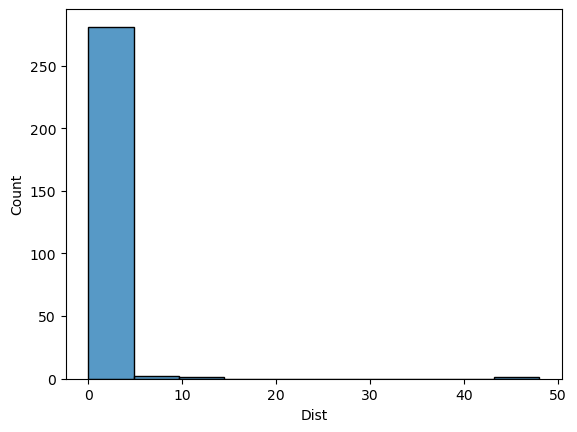

In [276]:
sns.histplot(data=SNP_dist.query("pid1 in @df_longitudinal_pids.pid"),
             x='Dist'
            )

In [277]:
SNP_dist.query("pid1 in @df_longitudinal_pids.pid").sort_values('Dist', ascending=False)

,Sample1,Sample2,Dist,pid1,pid2
27,MFS-157,MFS-156,48,T0245,T0245
180,MFS-552,MFS-551,10,T0067,T0067
177,MFS-545,MFS-544,5,T0057,T0057
109,MFS-396,MFS-395,5,T0330,T0330
280,MFS-890,MFS-811,4,T0428,T0428
...,...,...,...,...,...
118,MFS-415,MFS-414,0,T0340,T0340
119,MFS-417,MFS-416,0,T0341,T0341
120,MFS-419,MFS-418,0,T0342,T0342
121,MFS-42,MFS-41,0,T0070,T0070


In [278]:
df_trust_patients.query("pid=='T0067'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
322,T0067,S0067-01,MFS-551,MFS-551_lib64391,NaN,NaN,1.0,344.35,0.99,0.9889,...,18.0,18.0,2.0,0.339136,3.0,0.009784,2.2.1,2.2.1.1.1,2.0,1
323,T0067,S0067-07,MFS-552,MFS-552_lib64392,NaN,NaN,1.0,359.11,0.99,0.9898,...,18.0,18.0,2.0,0.339136,3.0,0.008839,2.2.1,2.2.1.1.1,2.0,7


In [280]:
df_WGS_summary.query("pid=='T0067'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Kraken_Unclassified_Percent,Median_Depth,Perc_Sites_20x,Sampling_Week
322,T0067,S0067-01,MFS-551,MFS-551_lib64391,NaN,NaN,1.0,344.35,0.99,0.9889,...,0.339136,3.0,0.009784,2.2.1,2.2.1.1.1,2.0,0.41,340.0,98.588586,1
323,T0067,S0067-07,MFS-552,MFS-552_lib64392,NaN,NaN,1.0,359.11,0.99,0.9898,...,0.339136,3.0,0.008839,2.2.1,2.2.1.1.1,2.0,0.57,355.0,98.586183,7


In [35]:
absent_to_fixed_summary.query("pid=='T0245'")

,pid,Sampling_Interval,SNP,Rate,Lineage,mix_phylotypes
157,T0245,7,0,0.0,2,2.2.M1.1


In [37]:
absent_to_fixed.query("pid=='T0245'").shape

(17, 11)

In [361]:
# df_longitudinal_pids = df_longitudinal_pids.merge(SNP_dist.query("Sample1 in @df_longitudinal_pids.SampleID & Sample2 in @df_longitudinal_pids.SampleID")[['pid1', 'Dist']].drop_duplicates().rename(columns={'pid1': 'pid', 'Dist': 'SNP_Dist'}))



<Axes: xlabel='SNP_Dist', ylabel='Count'>

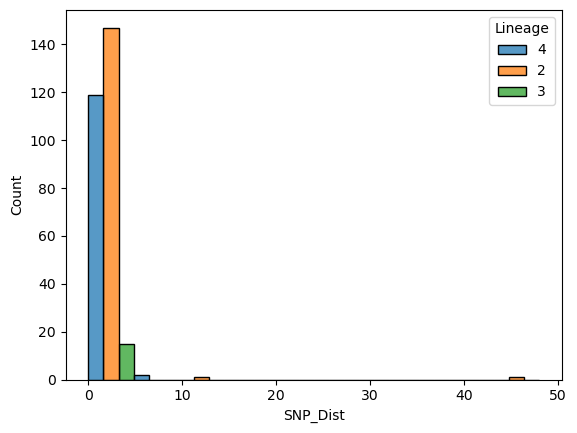

In [367]:
sns.histplot(data=df_longitudinal_pids.drop_duplicates(subset='pid'),
             x='SNP_Dist',
             hue='Lineage',
             multiple='dodge'
            )

In [375]:
df_longitudinal_pids.drop_duplicates(subset='pid').query("SNP_Dist >= 5")[['pid', 'Lineage', 'mix_phylotypes', 'SNP_Dist', 'Sampling_Interval']]

,pid,Lineage,mix_phylotypes,SNP_Dist,Sampling_Interval
78,T0057,4,4.1.2.1,5,3
92,T0067,2,2.2.M4.4,10,6
300,T0245,2,2.2.M1.1,48,7
392,T0330,4,4.1.1.1,5,7


In [ ]:
# Real absent to fixed cases:
# T0291: 1156928, 174751, and 3215815
# T0395
# T0470
# all T0245, but that seems like a lot of SNPs (17) gained. Could they be mismatched samples? Same lineage (2.2.M1.1)
# T0003
# T0057
# T0067: (all real), but 2697583 and 220415 are actually unfixed, but below 5%
# T0280
# T0288
# T0090
# T0203: 4303559, 3005492

In [260]:
# Not real:
# T0268: 4246567
# T0294: 851701 actually goes from unfixed to fixed
# T0036, 2467308
# T0056, 956679
# T0118
# T0203: 3583356
# T0439: 3378814 is actually unfixed to fixed

In [229]:
absent_to_fixed.query("Region=='Rv3433c'")

,pid,SNP,Change,Sample1,Sample2,Abs_Change,POS,REF,ALT,Region


In [208]:
df_longitudinal_pids.query("pid=='T0020'")

,pid,Original_ID,SampleID,Sampling_Week,screen_prevpid,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,...,p_val_wsrst,abs_diff,mix_index,mix_node,mix_phylotype,mix_prop,failed,mix_phylotypes,mix_props,Sampling_Interval
20,T0020,S0020-01,MFS-523,1,NaN,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,...,-1.0,inf,1,96,3.1.1.1,1.0,False,3.1.1.1,1.0,4
21,T0020,S0020-05,MFS-718,5,NaN,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,...,-1.0,inf,1,96,3.1.1.1,1.0,False,3.1.1.1,1.0,4
